# Build Makemore /w Manual Backpropagation

- Implement the same multi-layer perceptron as (part 2) with a hidden layer + batch normalization BUT without using Pytorch's loss.backward()
- Implement the backprop mechnanism by hand
- Also derive the derivatives analytically
- Verify that the results are identical to Pytorch's autograd engine
- Train the neural network using hand-written backprop mechanism

In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [13]:
# read the dataset (names.txt)
words = open('names.txt', 'r').read().splitlines()

In [14]:
chars = sorted(list(set('.abcdefghijklmnopqrstuvwxyz')))
chartoi = {s:i for i, s in enumerate(chars)}
itochar = {i:s for s,i in chartoi.items()}

In [158]:
# build the dataset

BLOCK_SIZE = 3 # Defines the context length ie. how many characters to use to predict the next one
X, Y = [], []

for w in words:
    #print(w)
    context = [0] * BLOCK_SIZE
    for ch in w + '.':
        idx = chartoi[ch]
        X.append(context)
        Y.append(idx)
        #print(f"{"".join(itochar[c] for c in context)} --> {ch}")
        context = context[1:] + [idx] # pop and push

X = torch.tensor(X)
Y = torch.tensor(Y)

In [159]:
# split the data into training, validation, and test set

N = X.shape[0] 
n_train = int(0.8 * N)
n_val = int(0.1 * N)
# n_test is whatever is left over

indices = torch.randperm(N)

train_indices = indices[:n_train]
val_indices = indices[n_train : n_train + n_val]
test_indices = indices[n_train + n_val:]

X_train, Y_train = X[train_indices], Y[train_indices]
X_val, Y_val = X[val_indices], Y[val_indices]
X_test, Y_test = X[test_indices], Y[test_indices]

print(f"Train: {X_train.shape}, {Y_train.shape}")
print(f"Val:   {X_val.shape}, {Y_val.shape}")
print(f"Test:  {X_test.shape}, {Y_test.shape}")

Train: torch.Size([182516, 3]), torch.Size([182516])
Val:   torch.Size([22814, 3]), torch.Size([22814])
Test:  torch.Size([22816, 3]), torch.Size([22816])


In [160]:
# utility function to compare manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [161]:
N_EMBED = 10 # the dimensionality of embedding vectors
N_HIDDEN = 64 # the num neurons of the hidden layer
VOCAB_SIZE = len(chars)

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# embedding layer params
C = torch.randn((VOCAB_SIZE, N_EMBED), generator=g)

# hidden layer params
W1 = torch.randn((BLOCK_SIZE * N_EMBED, N_HIDDEN), generator=g) * (5/3)/(BLOCK_SIZE * N_EMBED)**0.5
b1 = torch.randn(N_HIDDEN, generator=g) * 0.1

# batch norm params
bngain = torch.randn((1, N_HIDDEN))*0.1 + 1.0
bnbias = torch.randn((1, N_HIDDEN))*0.1

bnmean_running = torch.zeros((1, N_HIDDEN), requires_grad=False)
bnstd_running = torch.ones((1, N_HIDDEN), requires_grad=False)

# output layer params
W2 = torch.randn((N_HIDDEN, VOCAB_SIZE), generator=g) * 0.1
b2 = torch.randn(VOCAB_SIZE, generator=g) * 0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

for p in parameters:
    p.requires_grad = True

In [162]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
Xb, Yb = X_train[ix], Y_train[ix] # batch X,Y

In [163]:
# forward pass

emb = C[Xb] # maps chars to vectors in the embedding space
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

# Hidden layer - linear transform
hprebn = embcat @ W1 + b1

# Hidden layer - batch normalization
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv

hpreact = bngain * bnraw + bnbias

# Hidden layer - non-linear activation
h = torch.tanh(hpreact)

# Output layer - linear transformation
logits = h @ W2 + b2

# Output layer - softmax
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv

# Cross entropy loss
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.4189, grad_fn=<NegBackward0>)

In [164]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1/n
cmp('logprobs', dlogprobs, logprobs)

dprobs = dlogprobs * (1 / probs)
cmp('probs', dprobs, probs)

dcounts_sum_inv = (dprobs * counts).sum(1, keepdim=True)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)

dcounts_sum = (dcounts_sum_inv) * (-1 * counts_sum**-2)
cmp('counts_sum', dcounts_sum, counts_sum)

dcounts = (dprobs * counts_sum_inv) + (dcounts_sum * (torch.ones_like(counts)))
cmp('counts', dcounts, counts)

dnorm_logits = dcounts * counts
cmp('norm_logits', dnorm_logits, norm_logits)

dlogit_maxes = -dnorm_logits.sum(1, keepdim=True)
cmp('logit_maxes', dlogit_maxes, logit_maxes)

dlogits = dnorm_logits + dlogit_maxes*F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) 
cmp('logits', dlogits, logits)

dh = dlogits @ W2.T
cmp('h', dh, h)

dW2 = h.T @ dlogits
cmp('W2', dW2, W2)

db2 = dlogits.sum(0)
cmp('b2', db2, b2)

dhpreact = dh * (1 - h**2)
cmp('hpreact', dhpreact, hpreact)

dbngain = (dhpreact * bnraw).sum(0, keepdim=True)
cmp('bngain', dbngain, bngain)

dbnbias = dhpreact.sum(0, keepdim=True)
cmp('bnbias', dbnbias, bnbias)

dbnraw = bngain * dhpreact
cmp('bnraw', dbnraw, bnraw)

dbnvar_inv = (dbnraw * bndiff).sum(0, keepdim=True)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)

dbnvar = dbnvar_inv * (-0.5 * (bnvar + 1e-5)**-1.5)
cmp('bnvar', dbnvar, bnvar)

dbndiff2 = (dbnvar * (1/(n-1))).expand(bndiff2.shape[0], -1)
cmp('bndiff2', dbndiff2, bndiff2)

dbndiff = (dbnraw * bnvar_inv.expand(bndiff.shape[0], -1)) + (dbndiff2 * 2 * bndiff)
cmp('bndiff', dbndiff, bndiff)

dbnmeani = (dbndiff * -1 * torch.ones_like(dbndiff)).sum(0, keepdim=True)
cmp('bnmeani', dbnmeani, bnmeani)

dhprebn = dbndiff + (dbnmeani * (1/n)).expand(hprebn.shape[0], -1)
cmp('hprebn', dhprebn, hprebn)

dembcat = dhprebn @ W1.T
cmp('embcat', dembcat, embcat)

dW1 = embcat.T @ dhprebn
cmp('W1', dW1, W1)

db1 = dhprebn.sum(0)
cmp('b1', db1, b1)

demb = dembcat.view(emb.shape)
cmp('emb', demb, emb)

dC = torch.zeros_like(C)
for i in range(demb.shape[0]):
    for j in range(demb.shape[1]):
        dC[Xb[i][j]] += demb[i][j]
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

In [165]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.4188804626464844 diff: 0.0


In [166]:
# backward pass

dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09


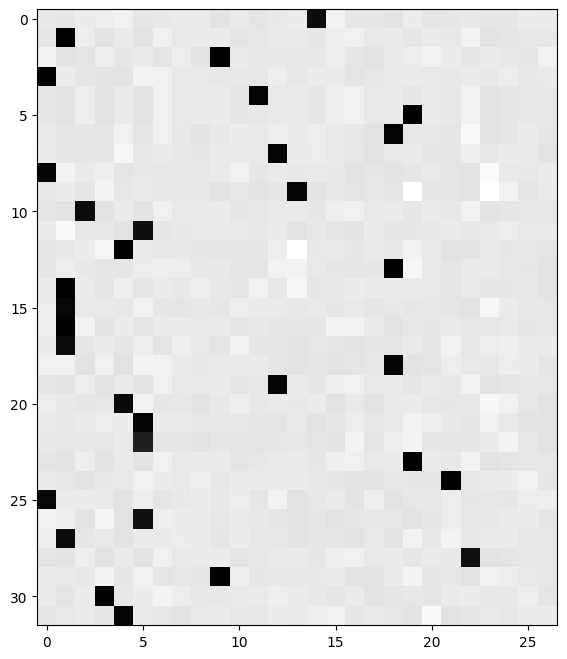

In [167]:
plt.figure(figsize=(8, 8))
plt.imshow(dlogits.detach(), cmap='gray')

In [168]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# BatchNorm paper: https://arxiv.org/abs/1502.03167

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [169]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 6.984919309616089e-10


In [176]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
vocab_size = VOCAB_SIZE
block_size = BLOCK_SIZE

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
#with torch.no_grad():

# kick off optimization
for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_train[ix], Y_train[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hprebn = embcat @ W1 + b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmean = hprebn.mean(0, keepdim=True)
  bnvar = hprebn.var(0, keepdim=True, unbiased=True)
  bnvar_inv = (bnvar + 1e-5)**-0.5
  bnraw = (hprebn - bnmean) * bnvar_inv
  hpreact = bngain * bnraw + bnbias
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward() # use this for correctness comparisons, delete it later!

  dC, dW1, db1, dW2, db2, dbngain, dbnbias = None, None, None, None, None, None, None
  grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]

  F.softmax(logits, 1)
  dlogits[range(n), Yb] -= 1
  dlogits /= n
  
  dh = dlogits @ W2.T
  dW2 = h.T @ dlogits
  db2 = dlogits.sum(0)
  dhpreact = dh * (1 - h**2)
  dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
  dembcat = dhprebn @ W1.T
  dW1 = embcat.T @ dhprebn
  db1 = dhprebn.sum(0)
  demb = dembcat.view(emb.shape)

  dC = torch.zeros_like(C)
  for m in range(demb.shape[0]):
    for j in range(demb.shape[1]):
      dC[Xb[m][j]] += demb[m][j]

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p, grad in zip(parameters, grads):
    p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
    #p.data += -lr * grad # new way of swole doge TODO: enable

  # track stats
  if i % 100 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  if i >= 100: # TODO: delete early breaking when you're ready to train the full net
    break

12297
      0/ 200000: 3.6260
    100/ 200000: 2.7725


In [ ]:
# useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

In [177]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[X_train]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

NameError: name 'Xtr' is not defined

In [ ]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))